# MLB-B9G2-06 · Integrated preprocessing pipeline — corrected

Created by Kaveesha Tennakoon.

Numbered, inspectable stages based on the supplied reference layout, adapted to **diabetes_prediction_dataset.csv**. Six original member roles retained. Read `docs/CHANGES_AND_AUDIT.md` before using older results.

## 01 · Load and inspect the assigned diabetes data

Eight input fields plus target `diabetes`. The reference Framingham columns are not copied.

In [1]:
from pathlib import Path
import sys, os
# In Colab: upload/extract the COMPLETE corrected project ZIP first.
# If needed set PROJECT_ROOT = Path('/content/MLB-B9G2-06').
PROJECT_ROOT = next((p for base in [Path.cwd(), *Path.cwd().parents, Path('/content')]
                     for p in [base, base/'MLB-B9G2-06']
                     if (p/'src/project_core.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Extract the complete project ZIP and set PROJECT_ROOT above.')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from project_core import *
from IPython.display import display
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=2)
raw, clean, X_train, X_test, y_train, y_test = load_dataset(PROJECT_ROOT)
print('Raw / clean / train / test:', len(raw), len(clean), len(X_train), len(X_test))

display(raw.head())
display(raw.dtypes.to_frame("dtype"))
display(raw.describe(include="all").T)

Raw / clean / train / test: 100000 96146 76916 19230


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


,dtype
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


## 02 · Member 1 — audit missingness and categories

There are no missing cells in the supplied dataset; no fabricated imputation claim. `No Info` is retained as an observed smoking category, not silently mapped to never.

gender {'Female': 58552, 'Male': 41430, 'Other': 18}
smoking_history {'No Info': 35816, 'never': 35095, 'former': 9352, 'current': 9286, 'not current': 6447, 'ever': 4004}


,missing_cells
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


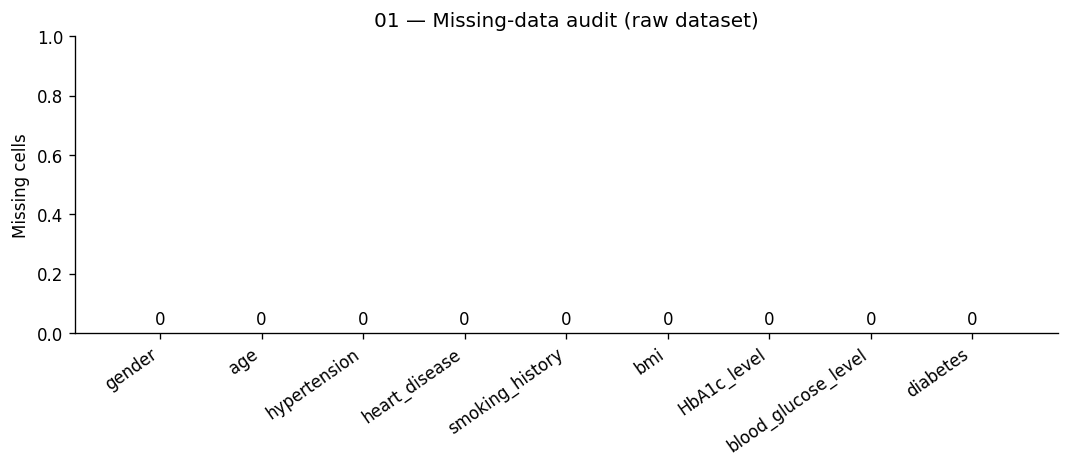

In [2]:
missing=raw.isna().sum()
display(missing.to_frame('missing_cells'))
for c in CAT: print(c, raw[c].value_counts().to_dict())
plt.figure(figsize=(9,4));bars=plt.bar(missing.index,missing.values);plt.xticks(rotation=35,ha='right');plt.ylim(0,max(1,missing.max()+1));plt.ylabel('Missing cells');plt.title('01 — Missing-data audit (raw dataset)')
for b,v in zip(bars,missing):plt.text(b.get_x()+b.get_width()/2,v+.03,str(v),ha='center')
savefig(PROJECT_ROOT,'01_missing_audit')

## 03 · Member 2 — exact duplicate removal

Deduplicate full rows before splitting. Original raw-row IDs remain the index. This counts records, not verified unique patients.

Duplicates removed: 3854 ; remaining: 96146


,raw,clean
diabetes,,
0,91500,87664
1,8500,8482


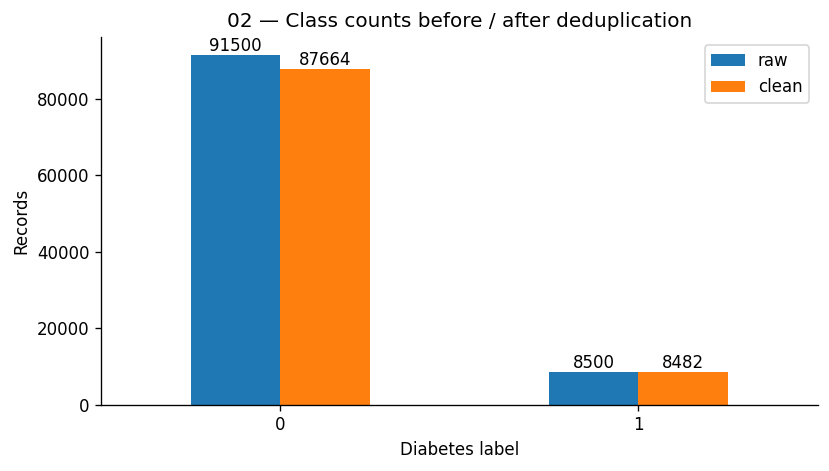

In [3]:
duplicates=int(raw.duplicated().sum())
print('Duplicates removed:',duplicates,'; remaining:',len(clean))
assert not clean.duplicated().any()
clean.to_csv(PROJECT_ROOT/'results/outputs/01_cleaned_deduplicated.csv',index_label='raw_row_id')
counts=pd.DataFrame({'raw':raw.diabetes.value_counts(),'clean':clean.diabetes.value_counts()}).sort_index()
display(counts)
ax=counts.plot.bar(figsize=(7,4),rot=0);ax.set(xlabel='Diabetes label',ylabel='Records',title='02 — Class counts before / after deduplication')
for c in ax.containers:ax.bar_label(c,fmt='%d')
savefig(PROJECT_ROOT,'02_duplicates_classes')

## 04 · Fix the train/test membership before learned preprocessing

80/20 stratified seed-42 split. Retained for comparability with the prior project. Because earlier test results have already been inspected, this is a reused benchmark, not a new untouched external validation cohort.

In [4]:
train_ids=set(X_train.index)
manifest=pd.DataFrame({'raw_row_id':clean.index,'split':['train' if i in train_ids else 'test' for i in clean.index]})
manifest.to_csv(PROJECT_ROOT/'results/outputs/split_manifest.csv',index=False)
assert not set(X_train.index)&set(X_test.index)
display(pd.DataFrame({'train':y_train.value_counts(),'test':y_test.value_counts()}).sort_index())
print('SHA256:',hashlib.sha256((PROJECT_ROOT/'data/raw/diabetes_prediction_dataset.csv').read_bytes()).hexdigest())

SHA256: f233fc470e904201f35310d061cb46ca0a6bc7ca5c3e428b769fb4f87f69929b


,train,test
diabetes,,
0,70130,17534
1,6786,1696


## 05 · Numeric correlation BEFORE transformations

Training rows only; every heatmap cell shows Pearson r to two decimals. Correlation is descriptive, not proof of causation or a reason to drop arbitrary columns.

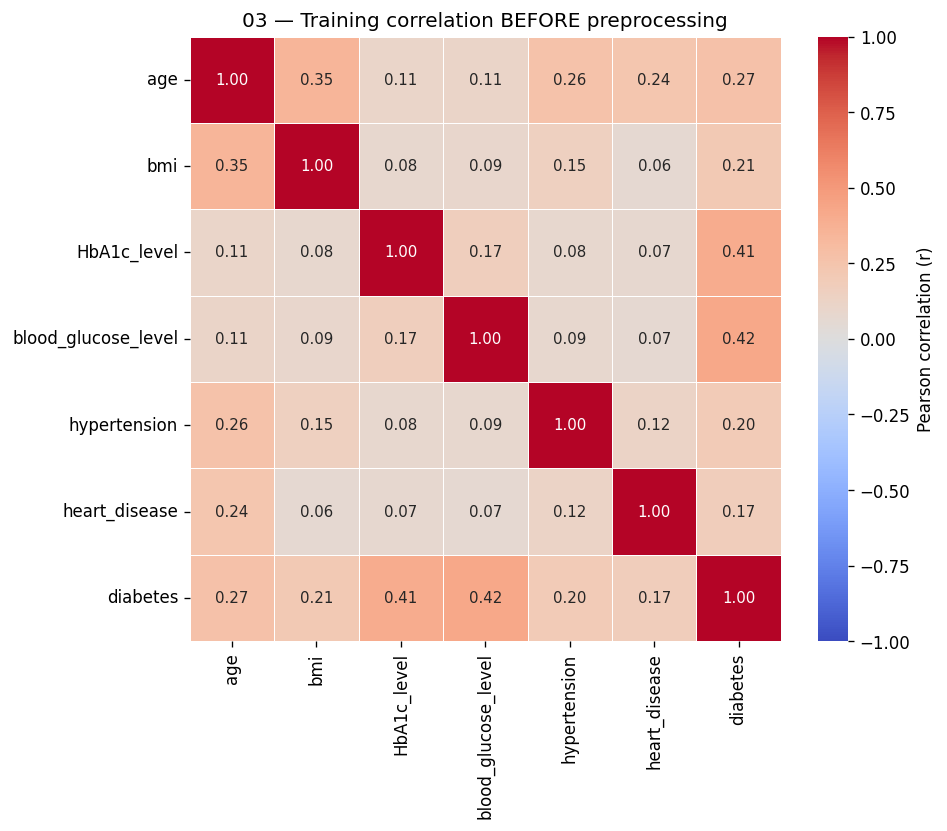

,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,diabetes
age,1.000,0.347,0.105,0.115,0.259,0.239,0.267
bmi,0.347,1.000,0.084,0.092,0.150,0.064,0.213
HbA1c_level,0.105,0.084,1.000,0.171,0.081,0.070,0.405
blood_glucose_level,0.115,0.092,0.171,1.000,0.086,0.069,0.423
hypertension,0.259,0.150,0.081,0.086,1.000,0.122,0.199
heart_disease,0.239,0.064,0.070,0.069,0.122,1.000,0.174
diabetes,0.267,0.213,0.405,0.423,0.199,0.174,1.000


In [5]:
before=X_train[CONT+BINARY].copy();before['diabetes']=y_train
corr_before=heatmap(before,'03 — Training correlation BEFORE preprocessing',PROJECT_ROOT,'03_correlation_before')
display(corr_before.round(3))

## 06 · Member 1 — fit imputations on training only

Numerical median and categorical/binary mode are learned on training rows. They are safety handling for future missing inputs, not a claim that this CSV contained nulls.

In [6]:
preprocessor=make_preprocessor('engineered_bmi_capped')
preprocessor.fit(X_train)
prep=preprocessor.named_steps['prepare']
imputed=prep.impute(X_train)
display(prep.medians_.to_frame('training_median'))
print('Modes:',prep.modes_)
assert imputed.isna().sum().sum()==0
imputed.to_csv(PROJECT_ROOT/'results/outputs/02_train_imputed.csv',index_label='raw_row_id')

Modes: {'gender': 'Female', 'smoking_history': 'never', 'hypertension': np.int64(0), 'heart_disease': np.int64(0)}


,training_median
age,43.00
bmi,27.32
HbA1c_level,5.80
blood_glucose_level,140.00


## 07 · Member 4 — inspect all continuous outliers; compare BMI capping

An IQR outlier is not automatically an error. Keep glucose and HbA1c signal. Only the enhanced candidate caps BMI using training bounds; the original-feature candidate keeps BMI too. BMI capping is a hypothesis under evaluation, not a clinically validated rule.

BMI training bounds: 13.7 39.540000000000006
BMI flags before: 4244
BMI flags after, SAME bounds: 0


,feature,q1,q3,lower,upper,flagged_train_rows,action
0,age,24.00,59.00,-28.5,111.50,0,retain values; do not treat IQR flag as error
1,bmi,23.39,29.85,13.7,39.54,4244,compare optional BMI capping
2,HbA1c_level,4.80,6.20,2.7,8.30,1041,retain values; do not treat IQR flag as error
3,blood_glucose_level,100.00,159.00,11.5,247.50,1598,retain values; do not treat IQR flag as error


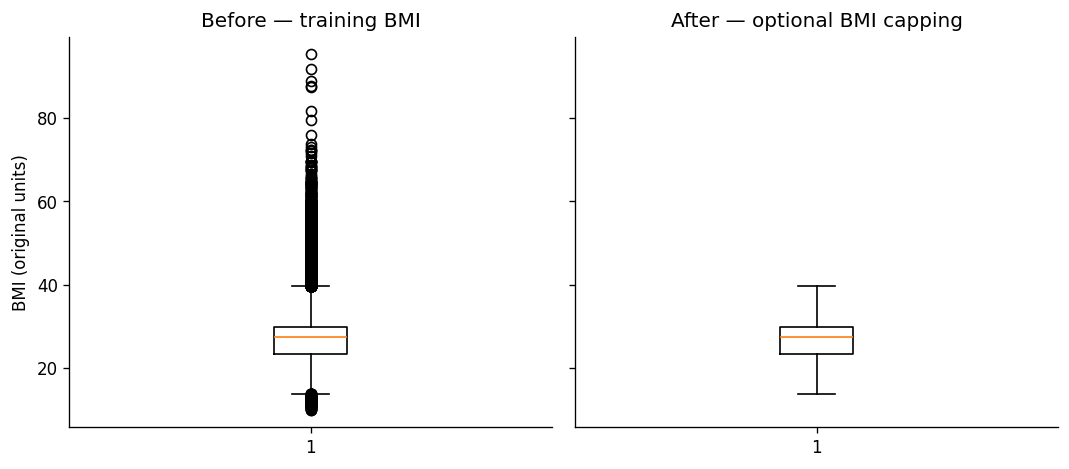

In [7]:
audit=outlier_audit(X_train);display(audit)
audit.to_csv(PROJECT_ROOT/'results/outputs/outlier_audit.csv',index=False)
capped=prep.cap(imputed)
lo,hi=prep.bmi_bounds_
print('BMI training bounds:',lo,hi)
print('BMI flags before:',int(((imputed.bmi<lo)|(imputed.bmi>hi)).sum()))
print('BMI flags after, SAME bounds:',int(((capped.bmi<lo)|(capped.bmi>hi)).sum()))
assert np.array_equal(capped.HbA1c_level,imputed.HbA1c_level)
assert np.array_equal(capped.blood_glucose_level,imputed.blood_glucose_level)
fig,axes=plt.subplots(1,2,figsize=(9,4),sharey=True)
axes[0].boxplot(imputed.bmi);axes[1].boxplot(capped.bmi)
axes[0].set_title('Before — training BMI');axes[1].set_title('After — optional BMI capping');axes[0].set_ylabel('BMI (original units)')
savefig(PROJECT_ROOT,'04_bmi_before_after')
capped.to_csv(PROJECT_ROOT/'results/outputs/03_train_bmi_handled.csv',index_label='raw_row_id')

## 08 · Member 6 — feature engineering after imputation/capping

Fixed age/BMI bands, condition count, and glucose–HbA1c interaction. No target is used. BMI bands are descriptive in this mixed-age dataset, not pediatric/adult clinical diagnoses.

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,age_group,bmi_group,condition_count,glucose_hba1c_interaction
0,Female,80.0,0,1,never,25.19,6.6,140,60_plus,25_to_under_30,1,924.0
1,Female,54.0,0,0,No Info,27.32,6.6,80,40_to_under_60,25_to_under_30,0,528.0
3,Female,36.0,0,0,current,23.45,5.0,155,20_to_under_40,18.5_to_under_25,0,775.0
4,Male,76.0,1,1,current,20.14,4.8,155,60_plus,18.5_to_under_25,2,744.0
6,Female,44.0,0,0,never,19.31,6.5,200,40_to_under_60,18.5_to_under_25,0,1300.0


,size,mean
age_group,,
under_20,15251,0.005442
20_to_under_40,19769,0.024129
40_to_under_60,22807,0.099838
60_plus,19089,0.206873


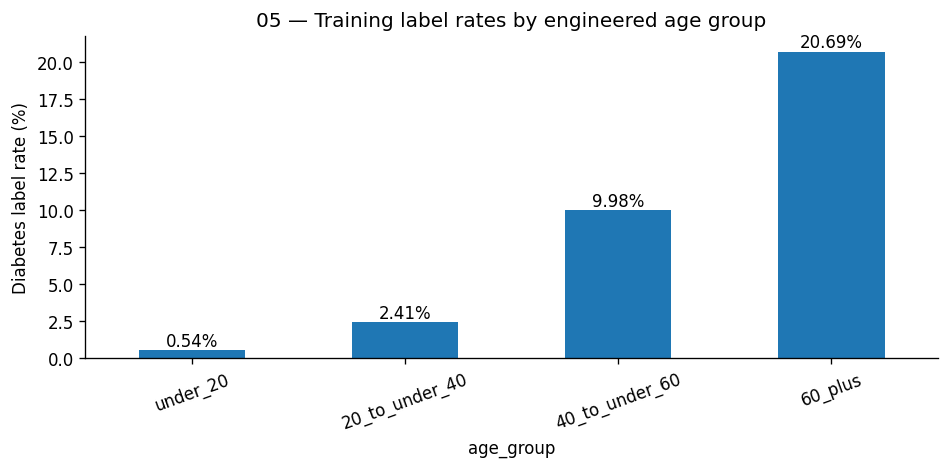

In [8]:
engineered=prep.transform(X_train)
display(engineered.head())
assert np.allclose(engineered.glucose_hba1c_interaction,engineered.blood_glucose_level*engineered.HbA1c_level)
engineered.to_csv(PROJECT_ROOT/'results/outputs/04_train_engineered.csv',index_label='raw_row_id')
rates=engineered.assign(diabetes=y_train).groupby('age_group',observed=True).diabetes.agg(['size','mean']).reindex(['under_20','20_to_under_40','40_to_under_60','60_plus'])
display(rates)
ax=(100*rates['mean']).plot.bar(figsize=(8,4),rot=20);ax.set(ylabel='Diabetes label rate (%)',title='05 — Training label rates by engineered age group')
for c in ax.containers:ax.bar_label(c,fmt='%.2f%%')
savefig(PROJECT_ROOT,'05_engineering_age_rates')

## 09 · Member 3 — one-hot encode nominal fields

No arbitrary integer ordering for gender/smoking. `handle_unknown="ignore"` means unseen categories become all-zero for that feature group.

Learned categories: {'gender': ['Female', 'Male', 'Other'], 'smoking_history': ['No Info', 'current', 'ever', 'former', 'never', 'not current'], 'age_group': ['20_to_under_40', '40_to_under_60', '60_plus', 'under_20'], 'bmi_group': ['18.5_to_under_25', '25_to_under_30', '30_plus', 'under_18.5']}


,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age_group_20_to_under_40,age_group_40_to_under_60,age_group_60_plus,age_group_under_20,bmi_group_18.5_to_under_25,bmi_group_25_to_under_30,bmi_group_30_plus,bmi_group_under_18.5
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


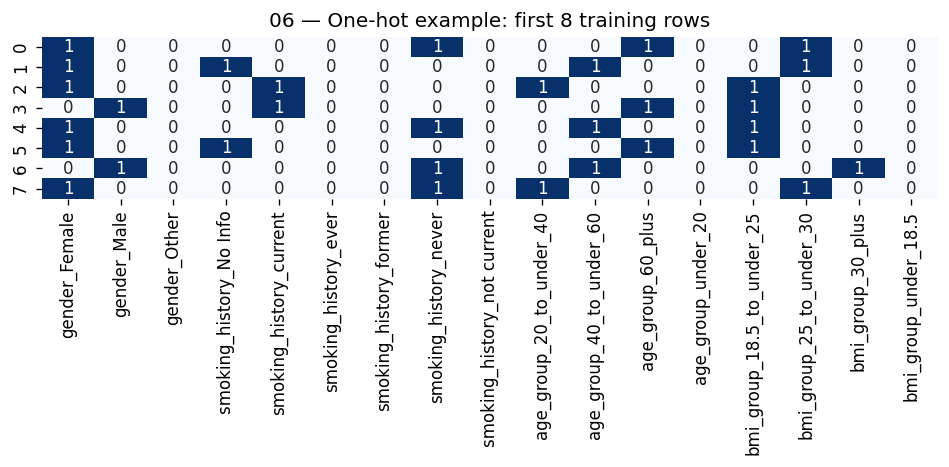

In [9]:
columns=preprocessor.named_steps['columns']
encoder=columns.named_transformers_['categorical']
catcols=categorical_columns(engineered)
encoded=encoder.transform(engineered[catcols])
encoded_names=encoder.get_feature_names_out(catcols)
display(pd.DataFrame(encoded[:8],columns=encoded_names))
print('Learned categories:',dict(zip(catcols,[list(c) for c in encoder.categories_])))
plt.figure(figsize=(8,4));sns.heatmap(pd.DataFrame(encoded[:8],columns=encoded_names),annot=True,fmt='.0f',cmap='Blues',cbar=False);plt.title('06 — One-hot example: first 8 training rows');savefig(PROJECT_ROOT,'06_encoding_heatmap')

## 10 · Member 5 — scale continuous/count/interaction fields

Binary flags remain 0/1. StandardScaler statistics are fitted only on training rows. Later data use transform, never a new fit.

,feature,before_mean,after_mean,after_std_ddof0
0,age,41.760982,-0.0,1.0
1,bmi,27.026417,0.0,1.0
2,HbA1c_level,5.530527,-0.0,1.0
3,blood_glucose_level,138.114281,-0.0,1.0
4,condition_count,0.118883,0.0,1.0
5,glucose_hba1c_interaction,771.328441,0.0,1.0


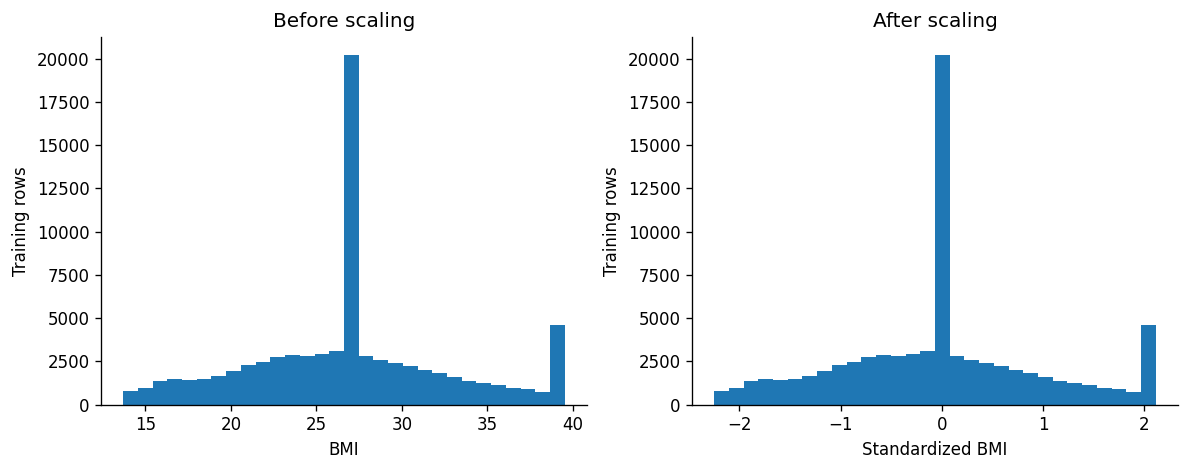

In [10]:
numcols=numeric_columns(engineered)
scaler=columns.named_transformers_['numeric']
scaled=scaler.transform(engineered[numcols])
scaling=pd.DataFrame({'feature':numcols,'before_mean':engineered[numcols].mean().values,'after_mean':scaled.mean(axis=0),'after_std_ddof0':scaled.std(axis=0)})
display(scaling.round(6))
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].hist(engineered.bmi,bins=30);axes[0].set(xlabel='BMI',ylabel='Training rows',title='Before scaling')
axes[1].hist(scaled[:,numcols.index('bmi')],bins=30);axes[1].set(xlabel='Standardized BMI',ylabel='Training rows',title='After scaling')
savefig(PROJECT_ROOT,'07_scaling_before_after')

## 11 · Annotated correlation AFTER transformations

Correctly use the transformed data. Positive linear scaling alone does not change Pearson correlation; capping and engineered features may change it.

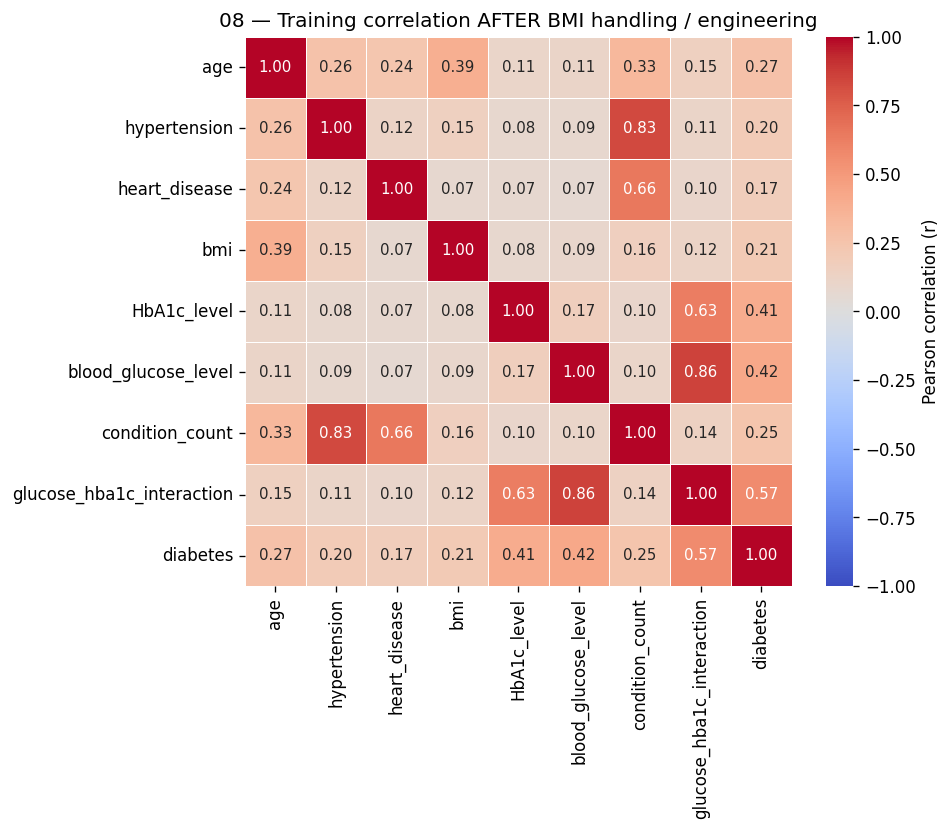

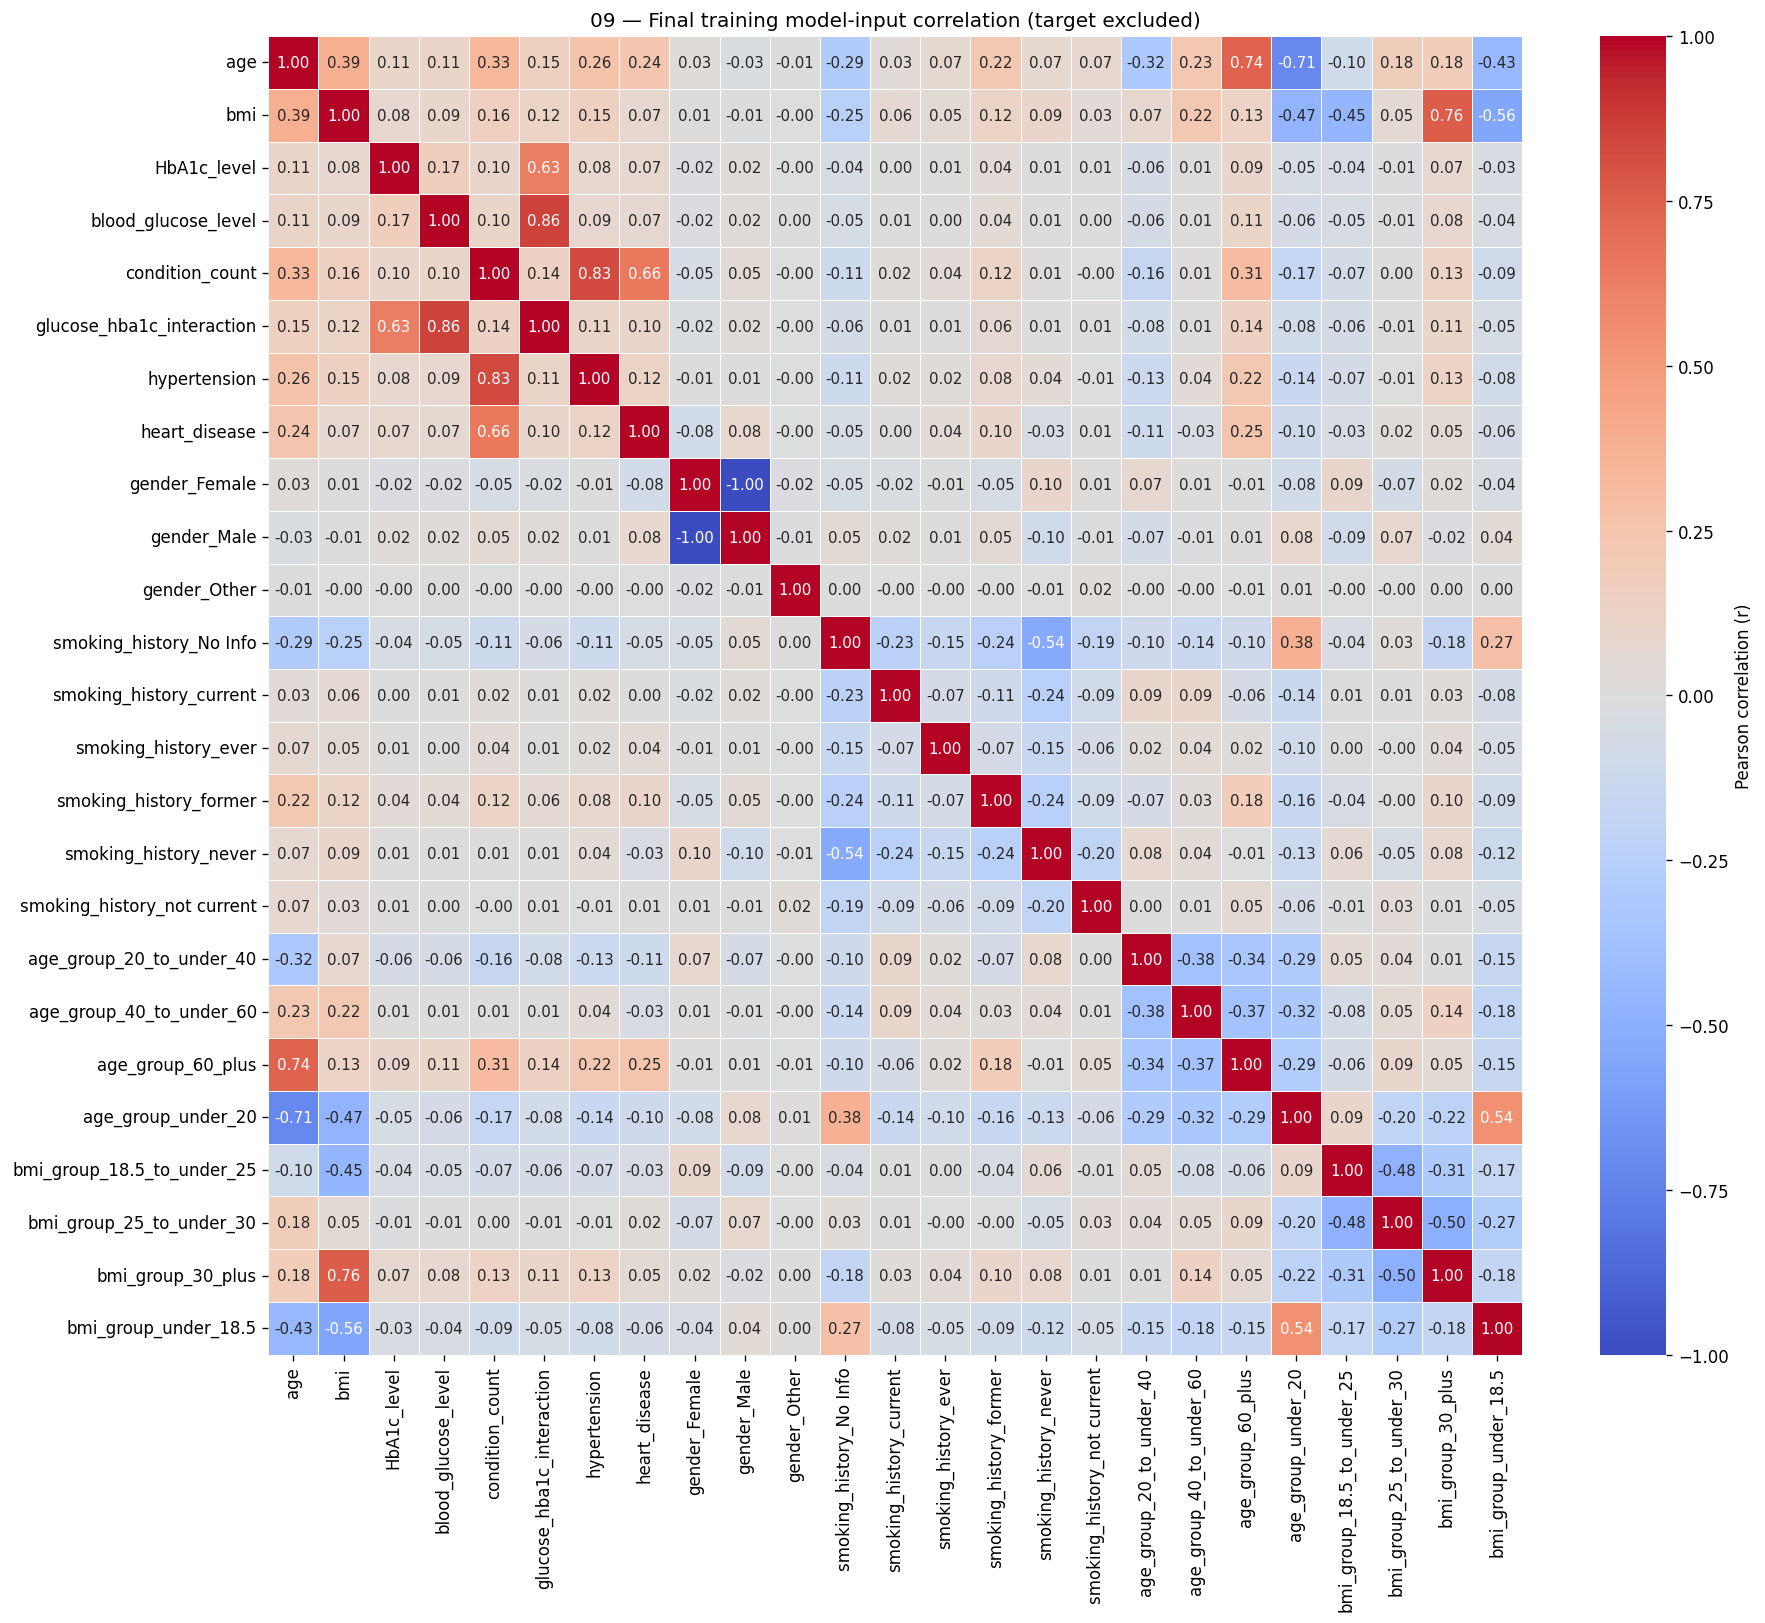

In [11]:
after=engineered.select_dtypes(include='number').copy();after['diabetes']=y_train
corr_after=heatmap(after,'08 — Training correlation AFTER BMI handling / engineering',PROJECT_ROOT,'08_correlation_after')
# Full encoded numeric matrix: separate larger figure for readable annotations.
train_matrix=preprocessor.transform(X_train);test_matrix=preprocessor.transform(X_test)
feature_names=preprocessor.get_feature_names_out()
full=pd.DataFrame(train_matrix,columns=feature_names,index=X_train.index)
heatmap(full,'09 — Final training model-input correlation (target excluded)',PROJECT_ROOT,'09_encoded_correlation')

## 12 · Export the EXACT transformed state, matrices and manifest

These matrices are for inspection/final fitted preprocessing. Model tuning starts from raw feature rows and refits the same preprocessing recipe inside each fold. Do not feed these pre-fitted matrices into cross-validation.

In [12]:
pd.DataFrame(train_matrix,columns=feature_names,index=X_train.index).to_csv(PROJECT_ROOT/'results/outputs/X_train_engineered.csv',index_label='raw_row_id')
pd.DataFrame(test_matrix,columns=feature_names,index=X_test.index).to_csv(PROJECT_ROOT/'results/outputs/X_test_engineered.csv',index_label='raw_row_id')
y_train.to_csv(PROJECT_ROOT/'results/outputs/y_train.csv',index_label='raw_row_id');y_test.to_csv(PROJECT_ROOT/'results/outputs/y_test.csv',index_label='raw_row_id')
joblib.dump(preprocessor,PROJECT_ROOT/'models/preprocessing_engineered.joblib',compress=3)
reloaded=joblib.load(PROJECT_ROOT/'models/preprocessing_engineered.joblib')
assert np.allclose(test_matrix,reloaded.transform(X_test))
assert np.isfinite(train_matrix).all() and np.isfinite(test_matrix).all()
assert 'diabetes' not in feature_names
metadata={'raw_rows':len(raw),'duplicates_removed':duplicates,'clean_rows':len(clean),'train_rows':len(X_train),'test_rows':len(X_test),'feature_names':list(feature_names),'bmi_bounds':prep.bmi_bounds_,'seed':SEED,'sklearn':sklearn.__version__,'raw_sha256':hashlib.sha256((PROJECT_ROOT/'data/raw/diabetes_prediction_dataset.csv').read_bytes()).hexdigest()}
(PROJECT_ROOT/'results/outputs/preprocessing_metadata.json').write_text(json.dumps(metadata,indent=2))
print('Verified: finite matrices, target excluded, serialization predictions/transforms unchanged.')
print('Shapes:',train_matrix.shape,test_matrix.shape)

Verified: finite matrices, target excluded, serialization predictions/transforms unchanged.
Shapes: (76916, 25) (19230, 25)


## 13 · Next: implementation
Open each `*_Model_*.ipynb`. Five classifiers use six candidate pipelines × three stratified folds. K-Means uses six label-free candidates and a common-space validation silhouette. Final test results remain a reused benchmark. All model pipelines are exported with their fitted preprocessing.